In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
import ast


In [16]:
df = pd.read_csv('/Users/oskarkarlsson/Desktop/DTU/4. Semester/Social Science/CompSci/Week3/Oskar/D2_temp_papers.csv')
df['author_ids'] = df['author_ids'].apply(ast.literal_eval)
df

,id,publication_year,cited_by_count,author_ids,title,abstract_inverted_index
0,https://openalex.org/W2095655043,2013,3006,"[https://openalex.org/A5090665793, https://ope...",Text as Data: The Promise and Pitfalls of Auto...,"{'Politics': [0], 'and': [1, 9, 67, 96, 99, 10..."
1,https://openalex.org/W2147453867,2006,2126,"[https://openalex.org/A5058815871, https://ope...",Experimental Study of Inequality and Unpredict...,"{'Hit': [0], 'songs,': [1], 'books,': [2], 'an..."
2,https://openalex.org/W2150375325,2007,1866,"[https://openalex.org/A5000679279, https://ope...","Influentials, Networks, and Public Opinion For...","{'A': [0], 'central': [1], 'idea': [2], 'in': ..."
3,https://openalex.org/W2096974619,2014,1830,"[https://openalex.org/A5082742221, https://ope...",Structural Topic Models for Open‐Ended Survey ...,"{'Collection': [0], 'and': [1, 14, 37, 78, 97,..."
4,https://openalex.org/W2049607688,2006,1696,"[https://openalex.org/A5066696247, https://ope...",Empirical Analysis of an Evolving Social Network,"{'Social': [0], 'networks': [1], 'evolve': [2]..."
...,...,...,...,...,...,...
370,https://openalex.org/W1602696812,2008,12,"[https://openalex.org/A5079997412, https://ope...",Change Detection in Social Networks,"{'Abstract': [0], ':': [1], 'Social': [2], 'ne..."
371,https://openalex.org/W3037966274,2020,12,"[https://openalex.org/A5077142904, https://ope...",A Dataset of Fact-Checked Images Shared on Wha...,"{'(Dataset': [0], 'paper).': [1], 'In': [2, 59..."
372,https://openalex.org/W4287773562,2020,12,"[https://openalex.org/A5050370761, https://ope...",Stance in Replies and Quotes (SRQ): A New Data...,"{'Automated': [0], 'ways': [1], 'to': [2, 16, ..."
373,https://openalex.org/W431568915,2015,12,"[https://openalex.org/A5086827245, https://ope...",Dissecting the Spirit of Gezi: Influence vs. S...,NaN


### Create the graph

In [ ]:
G = nx.Graph() # Create an empty graph

pair_counts = defaultdict(int)


for author_list in df['author_ids']: # Iterate through each paper's author list
    for i in range(len(author_list)): # Iterate through each author in the list
        for j in range(i + 1, len(author_list)): # Iterate through pairs of authors
            pair = tuple(sorted([author_list[i].strip(), author_list[j].strip()])) # Create a sorted tuple of unique author pairs
            pair_counts[pair] += 1 # Increment the count for this pair

# Convert the pair counts into a list of weighted edges for the graph
weighted_edgelist = [(a, b, count) for (a, b), count in pair_counts.items()]

# Create weighted edges in the graph
G.add_weighted_edges_from(weighted_edgelist) # Adds edges with weights in the metadata of the graph
weights = [G[u][v]['weight'] for u, v in G.edges()] # Extract the weights for visualization

### Visualize the graph

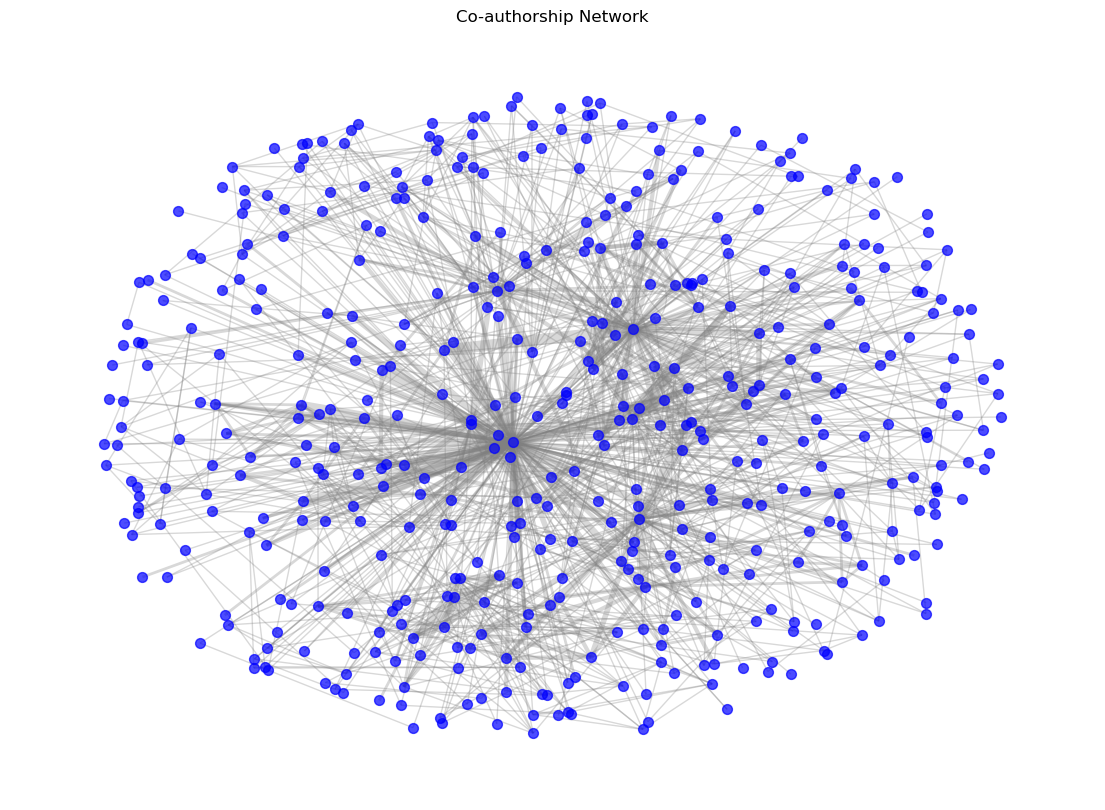

In [27]:
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)  # Position nodes using the spring layout
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='blue', alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray', width=weights)
plt.title('Co-authorship Network')
plt.axis('off')
plt.show()

### Add attributes to nodes